In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install datasets transformers evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvid

In [2]:
#data download and preprocessing

from datasets import load_dataset
from datasets import concatenate_datasets
from transformers import AutoTokenizer
from pympler import asizeof
from torch.utils.data import DataLoader
from collections import Counter

# Load datasets
mnli_dataset = load_dataset("glue", "mnli")
snli_dataset = load_dataset("snli")

# Remove 'idx' column from MNLI
mnli_dataset = {
    split: ds.remove_columns("idx") 
    for split, ds in mnli_dataset.items()
}

# Function to filter out invalid labels
def filter_valid(example):
    return example["label"] != -1

# Filter all SNLI splits
snli_dataset = {
    split: ds.filter(filter_valid)
    for split, ds in snli_dataset.items()
}

# Filter all MNLI splits except test split
mnli_dataset = {
    split: ds.filter(filter_valid) if "test" not in split else ds
    for split, ds in mnli_dataset.items()
}


train_dataset = concatenate_datasets([
    snli_dataset['train'], 
    mnli_dataset['train']
]).shuffle(seed=42)


validation_dataset = concatenate_datasets([
    snli_dataset['validation'], 
    mnli_dataset['validation_matched']
]).shuffle(seed=42)


validation_mismatched_dataset = mnli_dataset['validation_mismatched']


# Check the dataset structure
print(mnli_dataset)
print(snli_dataset)
# print(mnli_dataset["train"][0])  # Look at an example
# print(snli_dataset["train"][0])  # Look at an example

#snli all -1
# print(snli_dataset["test"][0])
# print(mnli_dataset["test_matched"][0])
# print(mnli_dataset["test_mismatched"][0])


# For RoBERTa model
tokenizer = AutoTokenizer.from_pretrained("roberta-base")


# tokenize_function with dynamic padding
def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_validation_mismatched = validation_mismatched_dataset.map(tokenize_function, batched=True)

# Tokenize test sets (if needed for evaluation)
tokenized_test_mnli_matched = mnli_dataset["test_matched"].map(tokenize_function, batched=True)
tokenized_test_mnli_mismatched = mnli_dataset["test_mismatched"].map(tokenize_function, batched=True)
tokenized_test_snli = snli_dataset["test"].map(tokenize_function, batched=True)


# Change dataset format to use "labels" instead of "label"
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_validation_mismatched = tokenized_validation_mismatched.rename_column("label", "labels")

tokenized_test_mnli_matched = tokenized_test_mnli_matched.rename_column("label", "labels")
tokenized_test_mnli_mismatched = tokenized_test_mnli_mismatched.rename_column("label", "labels")
tokenized_test_snli = tokenized_test_snli.rename_column("label", "labels")

# Set format for PyTorch
# train and validation split
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_validation.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_validation_mismatched.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
# test split
tokenized_test_mnli_matched.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test_mnli_mismatched.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test_snli.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



print(f"Train dataset size: {len(tokenized_train)}")
print(f"Validation dataset size: {len(tokenized_validation)}")
print(f"Validation mismatched size: {len(tokenized_validation_mismatched)}")

# attention_mask check 
print(tokenized_train[0]["attention_mask"])  # Expected: [1, 1, ..., 1, 0, ..., 0]

# Check the train dataset dtype and size
size_in_bytes = asizeof.asizeof(tokenized_train)
size_in_mb = size_in_bytes / (1024 * 1024)
print(f"Total size of tokenized_train: {size_in_mb:.2f} MB")

# Check label distribution-count of each sets 0,1,2
train_labels = tokenized_train["labels"].tolist()
print(f"Label distribution in train: {Counter(train_labels)}")

print(tokenized_train[0]["input_ids"].shape, tokenized_train[0]["input_ids"].dtype)
print(tokenized_train[0]["attention_mask"].shape, tokenized_train[0]["attention_mask"].dtype)
print(tokenized_train[0]["labels"].shape, tokenized_train[0]["labels"].dtype)


# Check data types of each column
sample = tokenized_train[0]  # Get the first example
for key, value in sample.items():
    print(f"Column: {key}, Data Type: {value.dtype}")


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

(…)alidation_matched-00000-of-00001.parquet:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

(…)dation_mismatched-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

test_matched-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

...

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/9796 [00:00<?, ? examples/s]

Map:   0%|          | 0/9847 [00:00<?, ? examples/s]

Map:   0%|          | 0/9824 [00:00<?, ? examples/s]

Train dataset size: 942069
Validation dataset size: 19657
Validation mismatched size: 9832
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Total size of tokenized_train: 574.08 MB
Label distribution in train: Counter({0: 314315, 2: 314090, 1: 313664})
torch.Size([16]) torch.int64
torch.Size([16]) torch.int64
torch.Size([]) torch.int64
Column: labels, Data Type: torch.int64
Column: input_ids, Data Type: torch.int64
Column: attention_mask, Data Type: torch.int64


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model, TaskType
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import math
from datetime import datetime, timezone
import inspect
from datasets import load_dataset, concatenate_datasets
from pympler import asizeof
from collections import Counter

class BertLoRAForNLI(nn.Module):
    def __init__(self, model_name="roberta-base", num_labels=3):
        super().__init__()
        
        # Load base model
        self.base_model = AutoModelForSequenceClassification.from_pretrained(
            model_name, 
            num_labels=num_labels
        )
        
        # LoRA Configuration
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            inference_mode=False,
            r=8,  # Rank
            lora_alpha=16,  # Scaling parameter
            lora_dropout=0.1,
            target_modules=["query", "value"],  # Apply LoRA to attention layers
        )
        
        # Apply LoRA to the model
        self.model = get_peft_model(self.base_model, lora_config)
        
        # Print trainable parameters
        self.model.print_trainable_parameters()

    def forward(self, input_ids, labels, attention_mask=None):
        """Forward pass compatible with your training loop
        
        RoBERTa doesn't use token_type_ids, so we ignore them
        """
        outputs = self.model(
            input_ids=input_ids,
            labels=labels,
            attention_mask=attention_mask
            # Note: token_type_ids removed for RoBERTa
        )
        return outputs.logits, outputs.loss
    
    def configure_optimizers(self, weight_decay, learning_rate, device, verbose=False):
        # Step 1: Collect trainable parameters (excluding frozen ones)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
    
        # Step 2: Separate weight decay (2D+ tensors) and no decay (biases, LayerNorm)
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]  # Weight matrices
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]  # Biases, LayerNorm
    
        # Step 3: Define optimizer parameter groups
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},  # Apply weight decay
            {'params': nodecay_params, 'weight_decay': 0.0}  # No weight decay
        ]

        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and 'cuda' in device
        
        # Debugging - Print parameter stats (optional)
        if verbose:
            num_decay_params = sum(p.numel() for p in decay_params)
            num_nodecay_params = sum(p.numel() for p in nodecay_params)
            print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params/1e6:.2f}M parameters")
            print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params/1e6:.2f}M parameters")
            print(f"Using fused AdamW: {use_fused}")

        # Create AdamW optimizer
        optimizer = torch.optim.AdamW(
            optim_groups, 
            lr=learning_rate, 
            betas=(0.9, 0.999),  # Momentum values
            eps=1e-8,  # Small epsilon for numerical stability
            fused=use_fused  # Enable fused version if available
        )
    
        return optimizer

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seeds for reproducibility
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

# Initialize the model
model = BertLoRAForNLI(model_name="roberta-base", num_labels=3)
model = model.to(device)


# Create data loaders
batch_size = 128
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

train_dataloader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_matched_dataloader = DataLoader(
    tokenized_validation,
    batch_size=batch_size,
    shuffle=False,  # Don't shuffle validation
    collate_fn=data_collator
)
val_mismatched_dataloader = DataLoader(
    tokenized_validation_mismatched,
    batch_size=batch_size,
    shuffle=False,  # Don't shuffle validation
    collate_fn=data_collator
)

print(f"Training batches: {len(train_dataloader)}") 
print(f"Validation (matched) batches: {len(val_matched_dataloader)}")
print(f"Validation (mismatched) batches: {len(val_mismatched_dataloader)}")

# Training hyperparameters
num_epochs = 1
max_steps = num_epochs * len(train_dataloader)
grad_clip = 1.0
eval_interval = 262 #128-788 #64-1577
log_interval = 100

# Learning rate setup
max_lr = 2e-4
min_lr = max_lr * 0.1
warmup_steps = int(0.03 * max_steps)
plateau = int(0.28 * max_steps)

print(f"Max steps: {max_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Plateau steps: {plateau}")

# Cosine learning rate scheduler with warmup
def get_lr(it):
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    if it < plateau:
        return max_lr
    if it > max_steps:
        return min_lr
    decay_ratio = (it - plateau) / (max_steps - plateau)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)

# Initialize optimizer
optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=max_lr, device=device, verbose=True)


# ---------------------------------------------------------------------------------------------------------

# History tracking for plots
train_losses = []
val_matched_losses = []
val_mismatched_losses = []
val_matched_accs = []
val_mismatched_accs = []
steps_history = []

def evaluate(dataloader, split_name):
    """Evaluation function with cleaner progress display"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc=f"Evaluating {split_name}", 
                        leave=True, position=0, 
                        ncols=80,
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    
    with torch.no_grad():
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            # Forward pass with autocast
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids, labels, attention_mask=attention_mask)
            
            # Get predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()
            
            # Update progress bar with current accuracy
            current_acc = (preds == labels).sum().item() / labels.size(0)
            progress_bar.set_postfix(batch_acc=f"{current_acc:.4f}", 
                                    loss=f"{loss.item():.4f}",
                                    refresh=False)
    
    # Calculate metrics
    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)
    
    # Print final metrics
    print(f"\n{split_name} Results | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")
    
    return {
        "loss": avg_loss,
        "accuracy": accuracy
    }

def plot_training_history():
    """Plot training and validation metrics."""
    plt.figure(figsize=(12, 8))
    
    # Plot losses
    plt.subplot(2, 1, 1)
    plt.plot(steps_history, train_losses, label='Train Loss')
    plt.plot(steps_history, val_matched_losses, label='Val Matched Loss')
    plt.plot(steps_history, val_mismatched_losses, label='Val Mismatched Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot accuracies
    plt.subplot(2, 1, 2)
    plt.plot(steps_history, val_matched_accs, label='Val Matched Accuracy')
    plt.plot(steps_history, val_mismatched_accs, label='Val Mismatched Accuracy')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    print("Training history plot saved to 'training_history.png'")

# Main training function
def train():
    global_step = 0
    best_val_acc = 0.0
    start_time = time.time()

    # Initialize history tracking
    global train_losses, val_matched_losses, val_mismatched_losses
    global val_matched_accs, val_mismatched_accs, steps_history
    
    # Main training loop
    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}")
        model.train()
        
        # Track metrics for this epoch
        epoch_losses = []
        
        # Use standard PyTorch dataloader iteration
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        for batch in progress_bar:
            if global_step >= max_steps:
                break
                
            t0 = time.time()
            
            # Get batch data and move to device
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass with autocast
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids, labels, attention_mask=attention_mask)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            # Update learning rate
            lr = get_lr(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            
            # Update weights
            optimizer.step()
            
            # Track epoch loss
            current_loss = loss.item()
            epoch_losses.append(current_loss)
            
            # Synchronize CUDA for accurate timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            # Calculate speed metrics
            t1 = time.time()
            dt = (t1 - t0)
            
            # Tokens processed calculation
            batch_size_actual = input_ids.size(0)
            sequence_length = input_ids.size(1)
            tokens_processed = batch_size_actual * sequence_length
            tokens_per_sec = tokens_processed / dt
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'lr': f'{lr:.2e}',
                'tok/s': f'{tokens_per_sec:.0f}'
            })
            
            # Log training metrics
            if global_step % log_interval == 0:
                print(f'step {global_step:6d} | loss: {current_loss:.6f} | lr: {lr:.4e} | '
                      f'dt: {dt*1000:.2f}ms | norm: {norm:.4f} | tok/sec: {tokens_per_sec:.2f}')
            
            # Evaluation
            if global_step > 0 and global_step % eval_interval == 0:
                print(f"\nEvaluating at step {global_step}...")
                val_matched_metrics = evaluate(val_matched_dataloader, "val_matched")
                val_mismatched_metrics = evaluate(val_mismatched_dataloader, "val_mismatched")
                
                # Calculate average validation accuracy
                val_acc = val_matched_metrics["accuracy"] #+ val_mismatched_metrics["accuracy"]) / 2
                
                # Track metrics for plotting
                avg_train_loss = sum(epoch_losses[-100:]) / min(len(epoch_losses), 100)
                train_losses.append(avg_train_loss)
                val_matched_losses.append(val_matched_metrics["loss"])
                val_mismatched_losses.append(val_mismatched_metrics["loss"])
                val_matched_accs.append(val_matched_metrics["accuracy"])
                val_mismatched_accs.append(val_mismatched_metrics["accuracy"])
                steps_history.append(global_step)
                
                # Save best model (LoRA weights only)
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    model.model.save_pretrained("best_lora_model")
                    print(f"New best validation accuracy: {best_val_acc:.4f}")
                
                # Generate and save plots
                plot_training_history()
                
                # Back to training mode
                model.train()
                print("")  # Add empty line for readability
            
            # Increment global step
            global_step += 1
        
        # End of epoch
        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"\nEpoch {epoch+1} completed | Average loss: {epoch_loss:.6f}")
        
    # Save final model (LoRA weights only)
    model.model.save_pretrained("final_lora_model")
    end_time = time.time()
    elapsed = end_time - start_time

    # Save training time
    elapsed_str = datetime.fromtimestamp(elapsed, tz=timezone.utc).strftime("%H:%M:%S")
    print(f"\nTraining completed in {elapsed:.2f} seconds ({elapsed_str})")
    print("Training completed. Final LoRA model saved to 'final_lora_model/'")


2025-07-22 13:28:08.587221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753190888.806133      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753190888.872858      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072
Training batches: 7360
Validation (matched) batches: 154
Validation (mismatched) batches: 77
Max steps: 7360
Warmup steps: 220
Plateau steps: 2060
num decayed parameter tensors: 50, with 0.89M parameters
num non-decayed parameter tensors: 2, with 0.00M parameters
Using fused AdamW: True


In [4]:
train()

Starting epoch 1/1


Epoch 1:   0%|          | 0/7360 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Epoch 1:   0%|          | 1/7360 [00:01<3:25:14,  1.67s/it, loss=1.1091, lr=9.09e-07, tok/s=6690]

step      0 | loss: 1.109070 | lr: 9.0909e-07 | dt: 1568.81ms | norm: 0.9898 | tok/sec: 6690.41


Epoch 1:   1%|▏         | 101/7360 [01:40<2:18:50,  1.15s/it, loss=1.0887, lr=9.18e-05, tok/s=12399]

step    100 | loss: 1.088684 | lr: 9.1818e-05 | dt: 1187.20ms | norm: 0.3590 | tok/sec: 12398.87


...


val_mismatched Results | Loss: 0.4004 | Accuracy: 0.8473


Epoch 1: 100%|█████████▉| 7337/7360 [2:58:14<13:38, 35.59s/it, loss=0.4613, lr=2.00e-05, tok/s=12447]

Training history plot saved to 'training_history.png'



Epoch 1: 100%|██████████| 7360/7360 [2:58:39<00:00,  1.46s/it, loss=0.4634, lr=2.00e-05, tok/s=12379]



Epoch 1 completed | Average loss: 0.466774

Training completed in 10719.79 seconds (02:58:39)
Training completed. Final LoRA model saved to 'final_lora_model/'


In [5]:
batch_size = 128

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

test_matched_mnli_dataloader = DataLoader(
    tokenized_test_mnli_matched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_mismatched_mnli_dataloader = DataLoader(
    tokenized_test_mnli_mismatched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_snli_dataloader = DataLoader(
    tokenized_test_snli,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)



print(f"Test matched size: {len(tokenized_test_mnli_matched)}")
print(f"Test mismatched size: {len(tokenized_test_mnli_mismatched)}")
print(f"Test SNLI size: {len(tokenized_test_snli)}")


Test matched size: 9796
Test mismatched size: 9847
Test SNLI size: 9824


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Evaluating SNLI Test Result:   0%|          | 0/77 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== SNLI Test Result Evaluation ===
Loss: 0.3025 | Accuracy: 0.8881 | F1 (weighted): 0.8882

=== Confusion Matrix Visualization ===


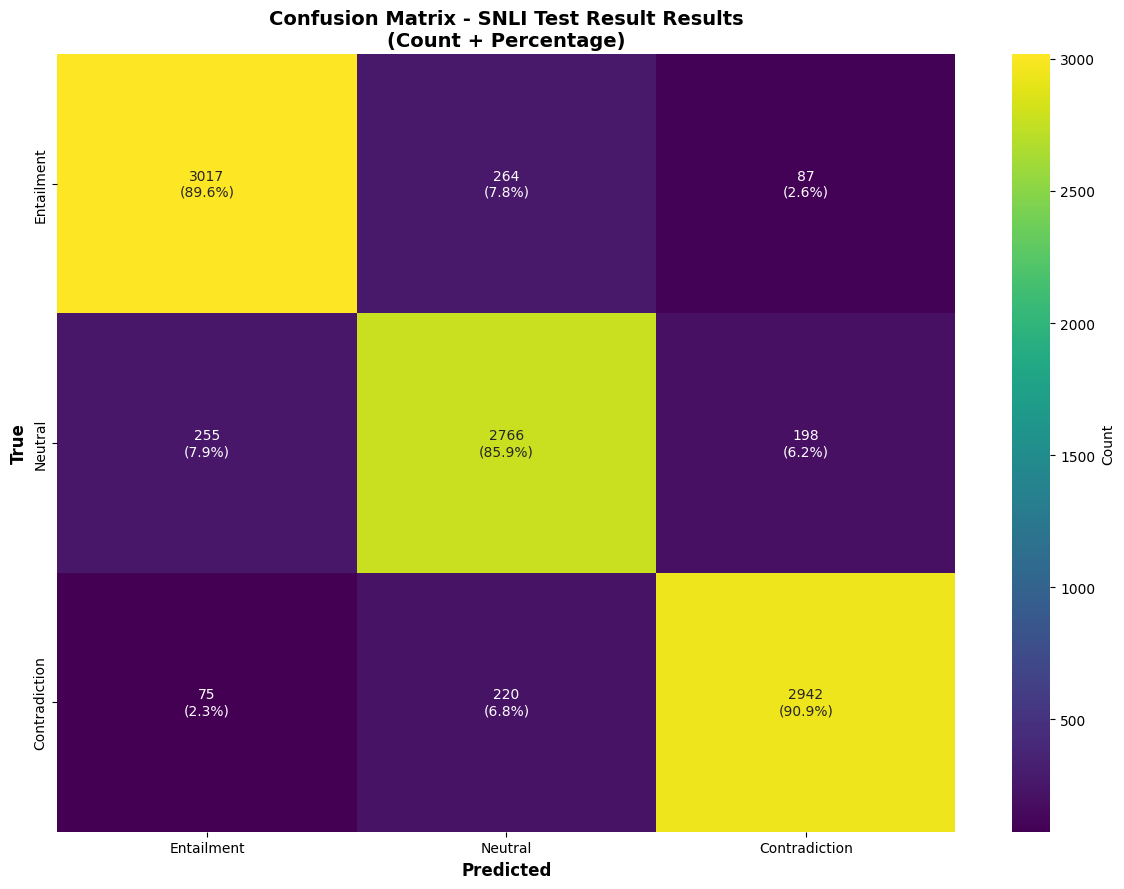

Confusion matrix saved to confusion_matrix_snli_test_result_20250722_163830.png

Classification Report - SNLI Test Result:
               precision    recall  f1-score   support

   Entailment       0.90      0.90      0.90      3368
      Neutral       0.85      0.86      0.86      3219
Contradiction       0.91      0.91      0.91      3237

     accuracy                           0.89      9824
    macro avg       0.89      0.89      0.89      9824
 weighted avg       0.89      0.89      0.89      9824


Per-Class Accuracy:
Entailment: 0.8958 accuracy (3017/3368)
Neutral: 0.8593 accuracy (2766/3219)
Contradiction: 0.9089 accuracy (2942/3237)

=== Summary of SNLI Test Evaluation ===
Loss: 0.3025
Accuracy: 0.8881
F1 (weighted): 0.8882
F1 (macro): 0.8880
F1 (micro): 0.8881

Per-Class Accuracy:
Entailment: 0.8958 (3017/3368)
Neutral: 0.8593 (2766/3219)
Contradiction: 0.9089 (2942/3237)


In [9]:
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report

from peft import PeftModel
from transformers import AutoModelForSequenceClassification


def final_evaluation(model, dataloader, split_name, class_names=None, device=None):
    """
    Comprehensive evaluation function for final reporting on a dataset.
    
    Args:
        model: PyTorch model in evaluation mode.
        dataloader: PyTorch DataLoader with input_ids, token_type_ids, label, attention_mask.
        split_name (str): Name of the dataset split (e.g., "Test", "Val Matched").
        class_names (list): List of class names (e.g., ["Entailment", "Neutral", "Contradiction"]). 
        device: Torch device. If None, uses model's device.
    
    Returns:
        dict: Metrics including loss, accuracy, F1 scores, confusion matrix, and per-class accuracy.
    """
    if device is None:
        device = next(model.parameters()).device
    
    if class_names is None:
        class_names = [f"Class {i}" for i in range(3)]  # Default for 3-class NLI task
    
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    num_examples = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False):
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            # Forward pass - Use the standard transformers interface
            # Since you're using PeftModel, use the standard forward method
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            logits = outputs.logits
            loss = outputs.loss
            
            # Compute predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            batch_size = input_ids.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item() * batch_size
            num_examples += batch_size
    
    # Convert to numpy arrays for sklearn
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate basic metrics
    correct = np.sum(y_true == y_pred)
    accuracy = correct / len(y_true)
    avg_loss = total_loss / num_examples
    
    # Calculate F1 scores
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class accuracy
    per_class_accuracy = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = np.where(y_true == cls_idx)[0]
        cls_correct = np.sum(y_pred[cls_indices] == y_true[cls_indices])
        cls_acc = cls_correct / len(cls_indices) if len(cls_indices) > 0 else 0
        per_class_accuracy[cls_name] = {
            "accuracy": cls_acc,
            "correct": int(cls_correct),
            "total": len(cls_indices)
        }
    
    # Print metrics
    print(f"\n=== {split_name} Evaluation ===")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f} | F1 (weighted): {f1_weighted:.4f}")
    
    # Enhanced confusion matrix visualization
    print(f"\n=== Confusion Matrix Visualization ===")
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.figure(figsize=(12, 9))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create custom annotations with count + percentage
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
        annotations.append(row)
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - {split_name} Results\n(Count + Percentage)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    plot_filename = f'confusion_matrix_{split_name.lower().replace(" ", "_")}_{timestamp}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to {plot_filename}")
    
    # Print classification report
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(f"\nClassification Report - {split_name}:\n{report}")
    
    # Print per-class accuracy
    print(f"\nPer-Class Accuracy:")
    for cls_name, stats in per_class_accuracy.items():
        print(f"{cls_name}: {stats['accuracy']:.4f} accuracy "
              f"({stats['correct']}/{stats['total']})")
    
    # Return comprehensive metrics
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm.tolist(),
        "per_class_accuracy": per_class_accuracy
    }


# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the base model first
base_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", 
    num_labels=3
)

# Load the LoRA adapter on top of base model
model = PeftModel.from_pretrained(
    base_model, 
    "best_lora_model"  # Path to your saved LoRA weights
)

model = model.to(device)
model.eval()

# Define class names for NLI task
class_names = ["Entailment", "Neutral", "Contradiction"]

# Run final evaluation
metrics = final_evaluation(
    model=model,
    dataloader=test_snli_dataloader,  # Make sure this variable exists
    split_name="SNLI Test Result",
    class_names=class_names,
    device=device
)


# Optionally, print a summary of key metrics
print("\n=== Summary of SNLI Test Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")

   

best_lora_model					       final_lora_model
confusion_matrix_snli_test_result_20250722_163830.png  training_history.png


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


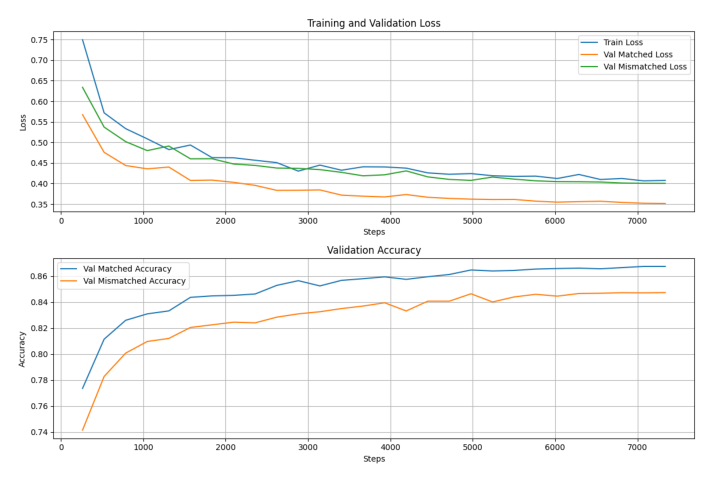


=== Confusion Matrix Visualization ===


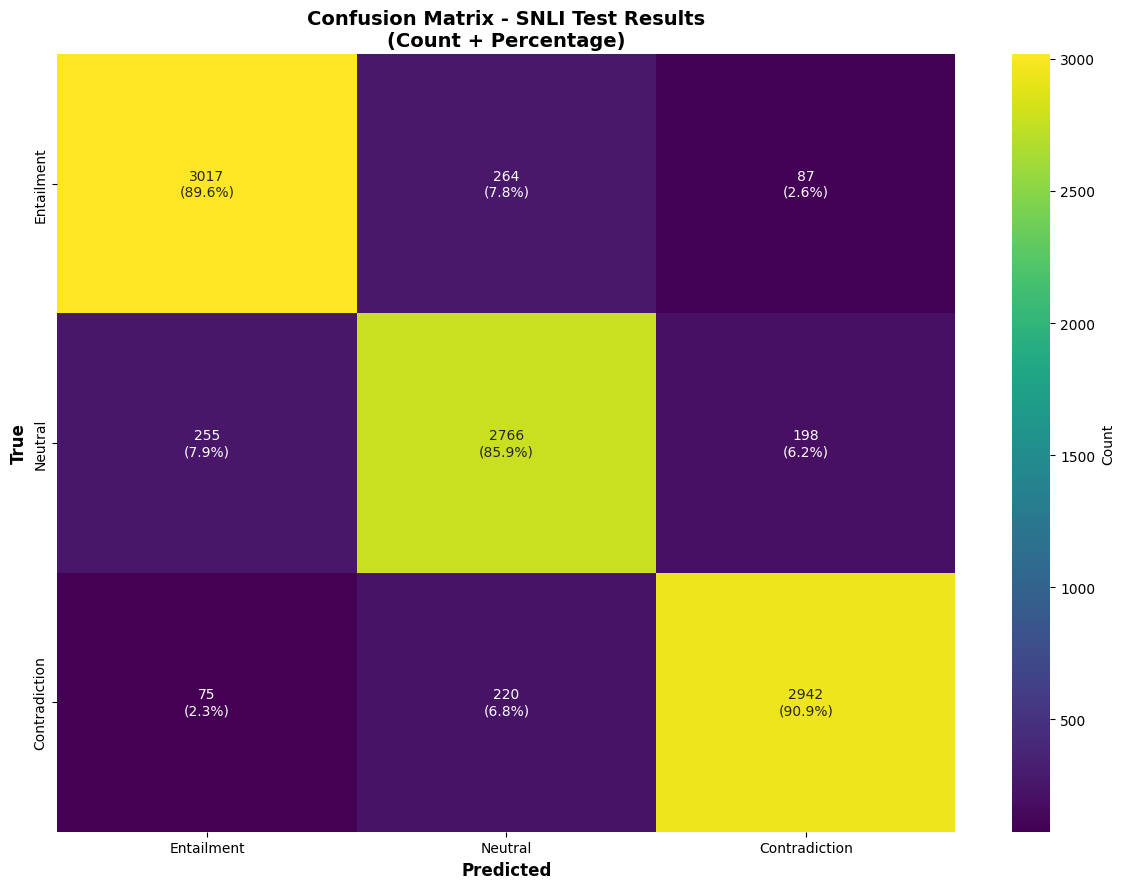

In [10]:
!ls
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('training_history.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

# Display the confusion matrix heatmap again
print("\n=== Confusion Matrix Visualization ===")
plt.figure(figsize=(12, 9))
cm = np.array(metrics['confusion_matrix'])

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create custom annotations with count + percentage
annotations = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
    annotations.append(row)

sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('True', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - SNLI Test Results\n(Count + Percentage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()  # This will display the plot

In [11]:
# anli dataset preprocessing
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding

# Load the ANLI dataset
anli_dataset = load_dataset("anli")
# print(anli_dataset) #original structure


# Remove 'uid' and 'reason' columns from all ANLI splits
anli_dataset = {
    split: ds.remove_columns(["uid", "reason"])
    for split, ds in anli_dataset.items()
}

# Function to filter out invalid labels
def filter_valid(example):
    return example["label"] != -1

# Filter all SNLI splits
anli_dataset = {
    split: ds.filter(filter_valid)
    for split, ds in anli_dataset.items()
}

print(anli_dataset)

# Look at an example from each round
# print("R1 example:", anli_dataset["test_r1"][0])
# print("R2 example:", anli_dataset["test_r2"][0])
# print("R3 example:", anli_dataset["test_r3"][0])

#combine r1,r2,r3

test_dataset_anli_r123 = concatenate_datasets([
    anli_dataset["test_r1"],
    anli_dataset["test_r2"],
    anli_dataset["test_r3"]
]).shuffle(seed=42)


# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_anli_test_r1 = anli_dataset["test_r1"].map(tokenize_function, batched=True)
tokenized_anli_test_r2 = anli_dataset["test_r2"].map(tokenize_function, batched=True)
tokenized_anli_test_r3 = anli_dataset["test_r3"].map(tokenize_function, batched=True)

tokenized_anli_test_r123 = test_dataset_anli_r123.map(tokenize_function, batched=True)


tokenized_anli_test_r1 = tokenized_anli_test_r1.rename_column("label", "labels")
tokenized_anli_test_r2 = tokenized_anli_test_r2.rename_column("label", "labels")
tokenized_anli_test_r3 = tokenized_anli_test_r3.rename_column("label", "labels")
tokenized_anli_test_r123 = tokenized_anli_test_r123.rename_column("label", "labels")

tokenized_anli_test_r1.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r2.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r3.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r123.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])


batch_size = 64

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

anli_test_r1_dataloader = DataLoader(
    tokenized_anli_test_r1,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r2_dataloader = DataLoader(
    tokenized_anli_test_r2,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r3_dataloader = DataLoader(
    tokenized_anli_test_r3,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r123_dataloader = DataLoader(
    tokenized_anli_test_r123,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)


README.md: 0.00B [00:00, ?B/s]

plain_text/train_r1-00000-of-00001.parqu(…):   0%|          | 0.00/3.14M [00:00<?, ?B/s]

plain_text/dev_r1-00000-of-00001.parquet:   0%|          | 0.00/351k [00:00<?, ?B/s]

plain_text/test_r1-00000-of-00001.parque(…):   0%|          | 0.00/353k [00:00<?, ?B/s]

plain_text/train_r2-00000-of-00001.parqu(…):   0%|          | 0.00/6.53M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Evaluating ANLI R2 0-shot Test Result:   0%|          | 0/16 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R2 0-shot Test Result Evaluation ===
Loss: 1.1966 | Accuracy: 0.3280 | F1 (weighted): 0.2190

=== Confusion Matrix Visualization ===


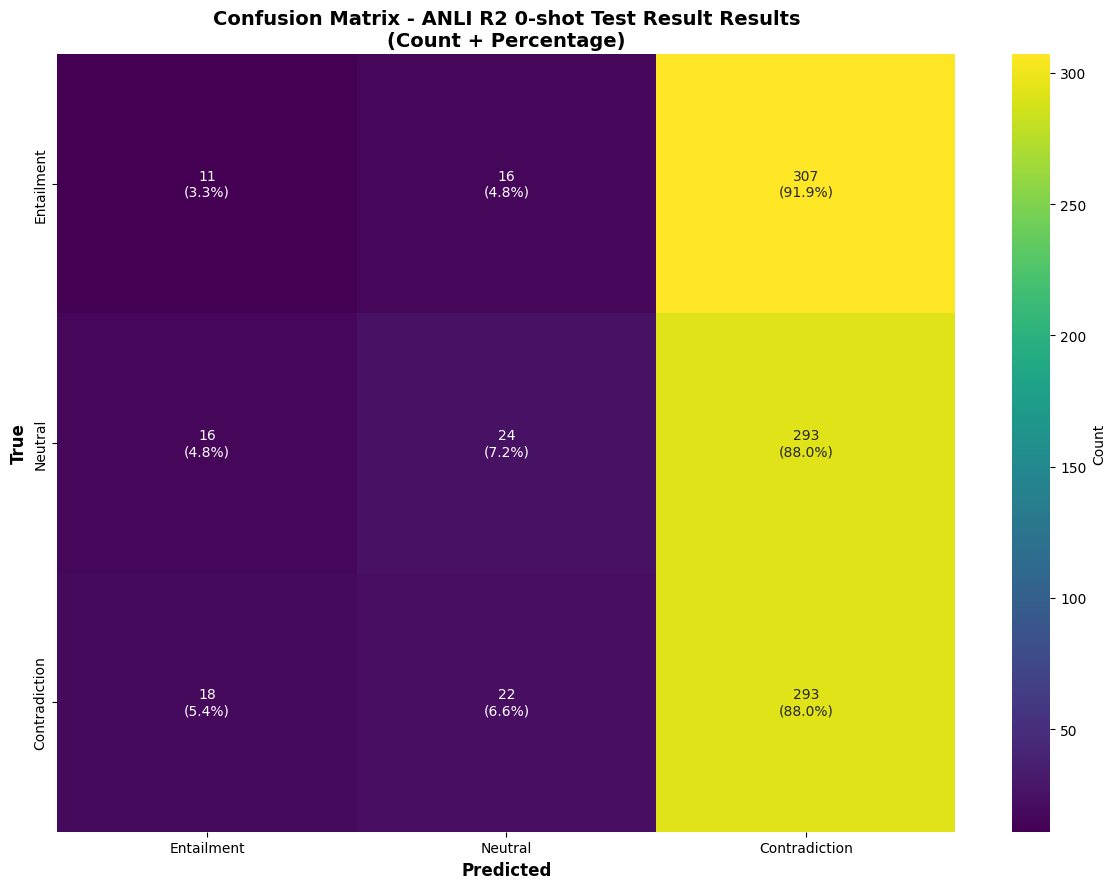

Confusion matrix saved to confusion_matrix_anli_r2_0-shot_test_result_20250722_164000.png

Classification Report - ANLI R2 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.24      0.03      0.06       334
      Neutral       0.39      0.07      0.12       333
Contradiction       0.33      0.88      0.48       333

     accuracy                           0.33      1000
    macro avg       0.32      0.33      0.22      1000
 weighted avg       0.32      0.33      0.22      1000


Per-Class Accuracy:
Entailment: 0.0329 accuracy (11/334)
Neutral: 0.0721 accuracy (24/333)
Contradiction: 0.8799 accuracy (293/333)

=== Summary of ANLI Test R2 Evaluation ===
Loss: 1.1966
Accuracy: 0.3280
F1 (weighted): 0.2190
F1 (macro): 0.2192
F1 (micro): 0.3280

Per-Class Accuracy:
Entailment: 0.0329 (11/334)
Neutral: 0.0721 (24/333)
Contradiction: 0.8799 (293/333)


Evaluating ANLI R3 0-shot Test Result:   0%|          | 0/19 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R3 0-shot Test Result Evaluation ===
Loss: 1.2172 | Accuracy: 0.3267 | F1 (weighted): 0.2094

=== Confusion Matrix Visualization ===


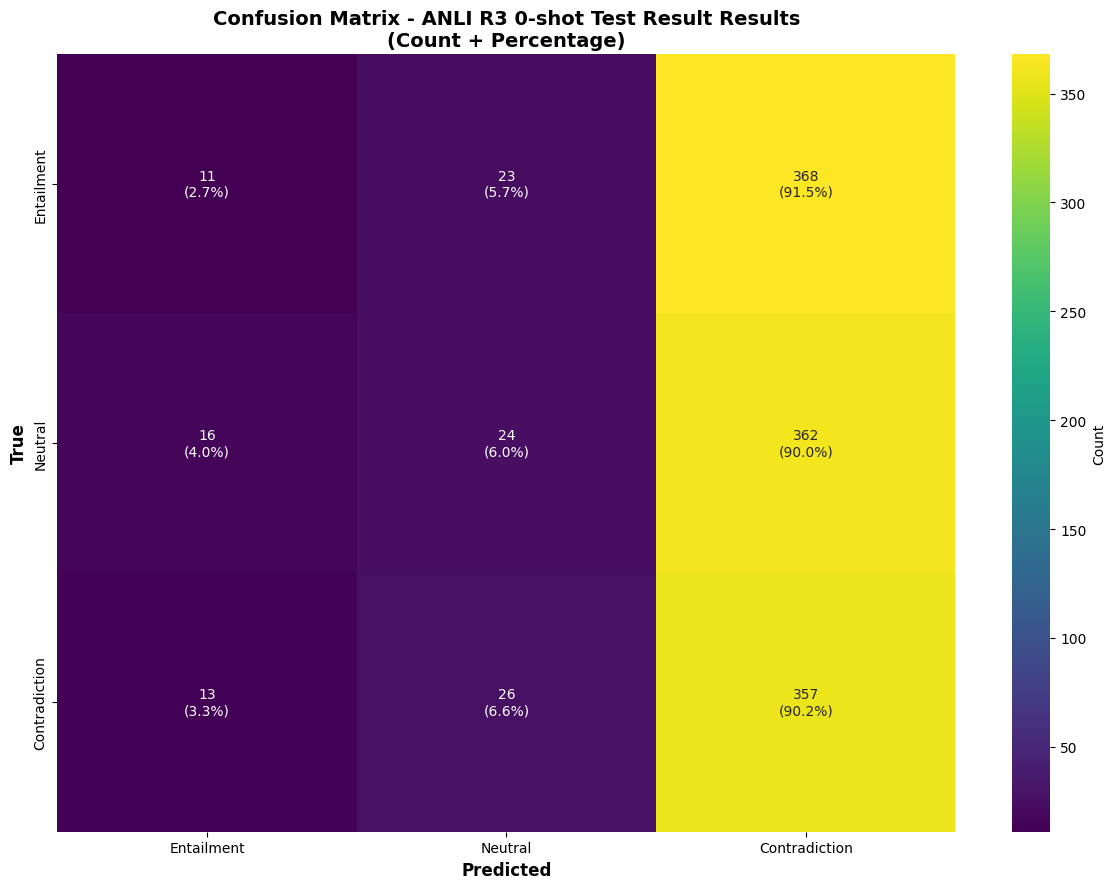

Confusion matrix saved to confusion_matrix_anli_r3_0-shot_test_result_20250722_164005.png

Classification Report - ANLI R3 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.28      0.03      0.05       402
      Neutral       0.33      0.06      0.10       402
Contradiction       0.33      0.90      0.48       396

     accuracy                           0.33      1200
    macro avg       0.31      0.33      0.21      1200
 weighted avg       0.31      0.33      0.21      1200


Per-Class Accuracy:
Entailment: 0.0274 accuracy (11/402)
Neutral: 0.0597 accuracy (24/402)
Contradiction: 0.9015 accuracy (357/396)

=== Summary of ANLI Test R3 Evaluation ===
Loss: 1.2172
Accuracy: 0.3267
F1 (weighted): 0.2094
F1 (macro): 0.2108
F1 (micro): 0.3267

Per-Class Accuracy:
Entailment: 0.0274 (11/402)
Neutral: 0.0597 (24/402)
Contradiction: 0.9015 (357/396)


In [12]:
# Run final evaluation on tokenized_test_ANLI
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r2_dataloader,
    split_name="ANLI R2 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R2 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


# Run final evaluation on tokenized_test_ANLI
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r3_dataloader,
    split_name="ANLI R3 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R3 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


Evaluating ANLI R1 0-shot Test Result:   0%|          | 0/16 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R1 0-shot Test Result Evaluation ===
Loss: 1.2134 | Accuracy: 0.3080 | F1 (weighted): 0.1971

=== Confusion Matrix Visualization ===


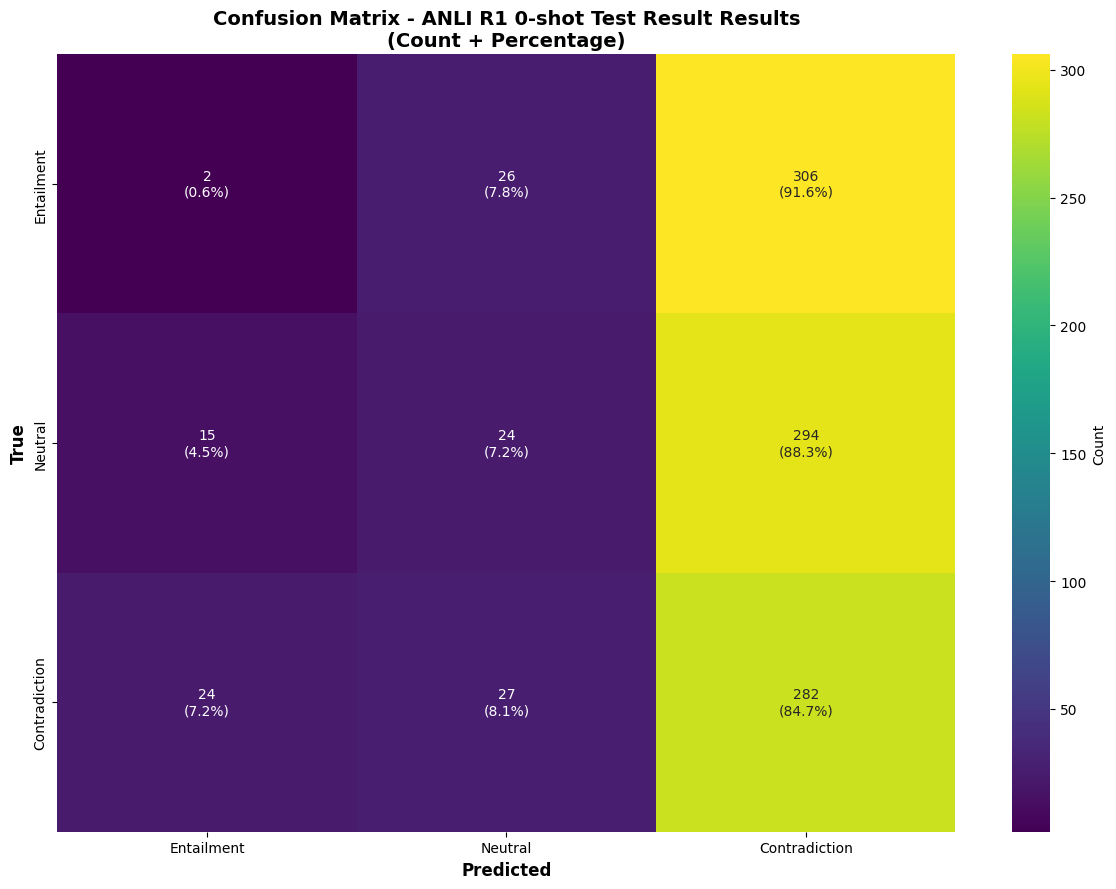

Confusion matrix saved to confusion_matrix_anli_r1_0-shot_test_result_20250722_164019.png

Classification Report - ANLI R1 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.05      0.01      0.01       334
      Neutral       0.31      0.07      0.12       333
Contradiction       0.32      0.85      0.46       333

     accuracy                           0.31      1000
    macro avg       0.23      0.31      0.20      1000
 weighted avg       0.23      0.31      0.20      1000


Per-Class Accuracy:
Entailment: 0.0060 accuracy (2/334)
Neutral: 0.0721 accuracy (24/333)
Contradiction: 0.8468 accuracy (282/333)

=== Summary of ANLI Test R1 Evaluation ===
Loss: 1.2134
Accuracy: 0.3080
F1 (weighted): 0.1971
F1 (macro): 0.1973
F1 (micro): 0.3080

Per-Class Accuracy:
Entailment: 0.0060 (2/334)
Neutral: 0.0721 (24/333)
Contradiction: 0.8468 (282/333)


Evaluating ANLI R123 0-shot Test Result:   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R123 0-shot Test Result Evaluation ===
Loss: 1.2096 | Accuracy: 0.3212 | F1 (weighted): 0.2086

=== Confusion Matrix Visualization ===


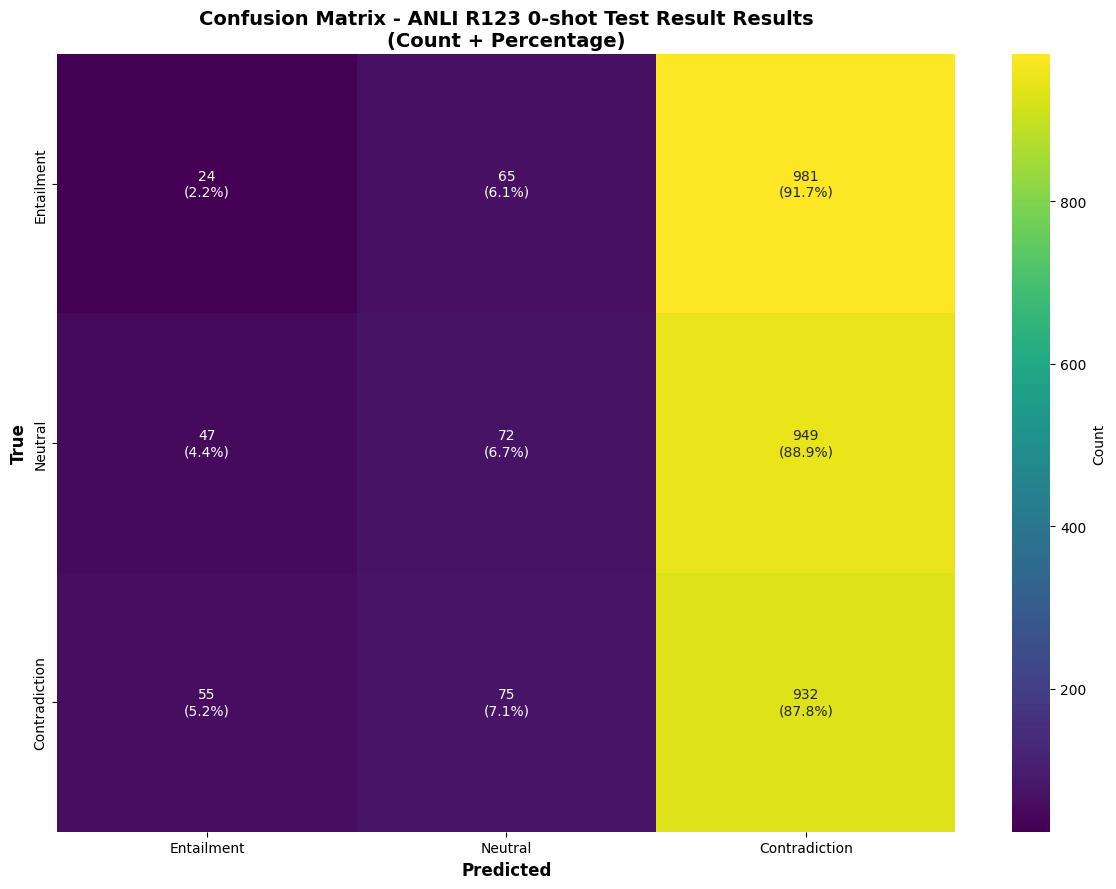

Confusion matrix saved to confusion_matrix_anli_r123_0-shot_test_result_20250722_164032.png

Classification Report - ANLI R123 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.19      0.02      0.04      1070
      Neutral       0.34      0.07      0.11      1068
Contradiction       0.33      0.88      0.48      1062

     accuracy                           0.32      3200
    macro avg       0.29      0.32      0.21      3200
 weighted avg       0.29      0.32      0.21      3200


Per-Class Accuracy:
Entailment: 0.0224 accuracy (24/1070)
Neutral: 0.0674 accuracy (72/1068)
Contradiction: 0.8776 accuracy (932/1062)

=== Summary of ANLI Test R123 Evaluation ===
Loss: 1.2096
Accuracy: 0.3212
F1 (weighted): 0.2086
F1 (macro): 0.2092
F1 (micro): 0.3212

Per-Class Accuracy:
Entailment: 0.0224 (24/1070)
Neutral: 0.0674 (72/1068)
Contradiction: 0.8776 (932/1062)


In [13]:
# Run final evaluation on tokenized_test_ANLI
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r1_dataloader,
    split_name="ANLI R1 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R1 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


# Run final evaluation on tokenized_test_ANLI
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r123_dataloader,
    split_name="ANLI R123 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R123 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


In [14]:
import os

def get_lora_size(lora_path):
    total_size = 0
    for root, dirs, files in os.walk(lora_path):
        for file in files:
            file_path = os.path.join(root, file)
            total_size += os.path.getsize(file_path)
    
    print(f"LoRA adapter size: {total_size:,} bytes")
    print(f"Size in MB: {total_size / (1024**2):.2f} MB")
    print(f"Size in GB: {total_size / (1024**3):.3f} GB")
    return total_size

# Usage
lora_size = get_lora_size("final_lora_model")

def calculate_total_deployment_size(base_model, lora_path):
    # Get base model size
    base_model_size = sum(p.numel() * p.element_size() for p in base_model.parameters())
    
    # Get LoRA adapter size
    lora_size = get_lora_size(lora_path)
    
    # Total size (base model dominates, LoRA adds minimal overhead)
    total_size = base_model_size + lora_size
    
    print(f"Base model size: {base_model_size:,} bytes ({base_model_size / (1024**3):.3f} GB)")
    print(f"LoRA adapter size: {lora_size:,} bytes ({lora_size / (1024**2):.2f} MB)")
    print(f"Total deployment size: {total_size:,} bytes ({total_size / (1024**2):.3f} MB)")
    print(f"Total deployment size: {total_size:,} bytes ({total_size / (1024**3):.3f} GB)")
    
    return total_size

# Usage
total_size = calculate_total_deployment_size(model.model, "final_lora_model")

LoRA adapter size: 3,564,459 bytes
Size in MB: 3.40 MB
Size in GB: 0.003 GB
LoRA adapter size: 3,564,459 bytes
Size in MB: 3.40 MB
Size in GB: 0.003 GB
Base model size: 502,143,000 bytes (0.468 GB)
LoRA adapter size: 3,564,459 bytes (3.40 MB)
Total deployment size: 505,707,459 bytes (482.280 MB)
Total deployment size: 505,707,459 bytes (0.471 GB)


In [ ]:
# clear cache memory

import torch
import gc

# Delete model, optimizer, and any large tensors
del model  # Replace with your model variable name
del optimizer  # Replace with your optimizer variable name
# Delete other large tensors if applicable, e.g., del train_loader

# Clear GPU memory cache
torch.cuda.empty_cache()

# Run garbage collection
#
gc.collect()

# Check memory usage again
print(f"Current GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Current GPU memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

In [15]:
print("har har mahadev")

har har mahadev
